In [1]:
import os
from openai import OpenAI
client = OpenAI(api_key = os.getenv("OPENAI_API_KEY"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import io
import inspect
import requests
import ChatAPICallFunctionsLib as cfl
import AutoSTMFuctionsLib as stmfl

In [15]:
functions_dict_path = 'toolsjsdict.json'
with open(functions_dict_path, 'r') as file:
    toolsjsdict = json.load(file)


tools_list = [stmfl.load_txt_from_idl,stmfl.plot_topo,stmfl.polybackRow]
files_to_load = ['06_10_24_002.txt','06_15_24_010.txt','06_16_24_006.txt']
array_pool = []

In [16]:
messages = [
        {"role": "system", "content": "The path to load data is %s, the fils to load under this path are %s" % ('Data', files_to_load)},
        {"role": "user", "content": 'load the txt file from given path and convert it into numpy array'}]

In [22]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (array_pool)},
        {"role": "user", "content": 'please use the plot function to plot all the arrays as topography images'}]


In [20]:
messages = [
        {"role": "system", "content": "The data arrays are: %s" % (array_pool)},
        {"role": "user", "content": 'please apply polybackRow function on all the arrays with polyord = %s' %('2')}]


Excuted function: [plot_topo] with arguments: {"topo": "x06_10_24_002", "title_name": "Topography of x06_10_24_002"}


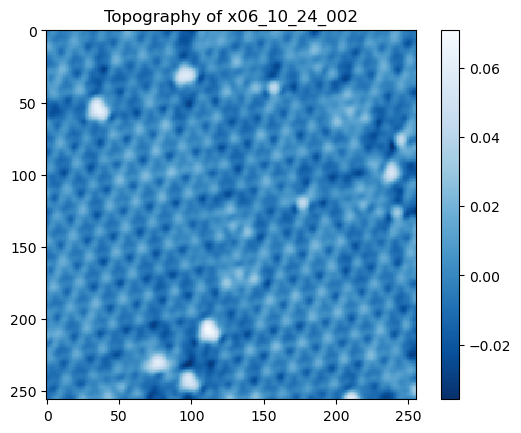

Excuted function: [plot_topo] with arguments: {"topo": "x06_15_24_010", "title_name": "Topography of x06_15_24_010"}


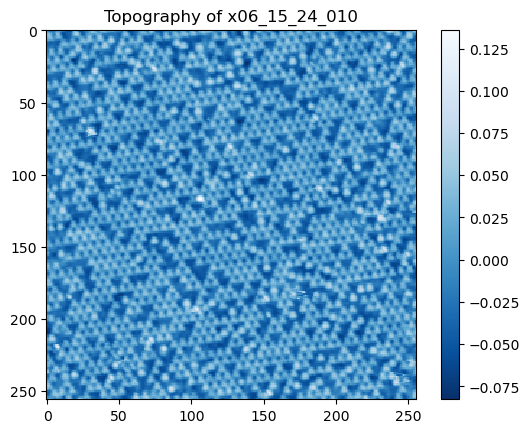

Excuted function: [plot_topo] with arguments: {"topo": "x06_16_24_006", "title_name": "Topography of x06_16_24_006"}


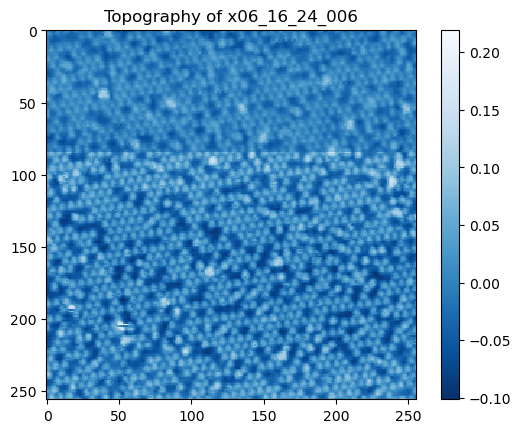

In [23]:
cfl.run_conversation1(messages = messages, tools_list = tools_list, toolsjsdict = toolsjsdict, global_namespace=globals())

In [ ]:
# model = 'gpt-4o'
# response = client.chat.completions.create(
#                 model="gpt-4o",
#                 messages=messages,
#                 tools=toolsjsdict,
#                 tool_choice="auto")
# response_message = response.choices[0].message.tool_calls
# print(response_message)

In [14]:
def polybackRow(data, polyord):
    """To subtract the background from an image using polynomial fitting. 

    Args:
        data_name (str): variable name of the image to subtract background.
        polyord (str): The order of polynomial fitting. It should be an integer number in string type. eg: '2'
    """
    curr_data = data
    
    xsize, ysize = curr_data.shape

    new_data = np.zeros((xsize, ysize))

    x = np.arange(1, xsize+1)

    for i in range(ysize):
        y = curr_data[:, i]
        pFit = np.polyfit(x, y, polyord)
        pFity = np.polyval(pFit, x)
        new_data[:, i] = y - pFity

    return new_data

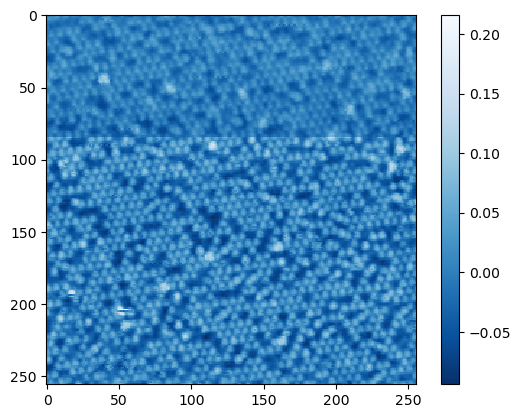

In [18]:
plt.imshow(polybackRow(x06_16_24_006,2), cmap = 'Blues'+'_r', interpolation = 'none')
plt.colorbar()
plt.title('')
plt.show()